# Computer Exercise 13.2 — Problem 6

## Levenberg–Marquardt 감쇠 $\lambda$ 와 신뢰영역의 등가성

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.2 Minimization of Multivariate Functions (continued)
> **풀이 일자**: Day 47
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

## 1. 문제 (원문)

> **6.** For a nonlinear least-squares problem, study the **damping parameter**
> $\lambda$ in the Levenberg–Marquardt step
> $(J^\top J + \lambda I)\mathbf p(\lambda) = -J^\top\mathbf r$. Show numerically that
> $\|\mathbf p(\lambda)\|$ is a **monotonically decreasing** function of $\lambda$,
> so that choosing $\lambda$ is equivalent to choosing a trust-region radius
> $\Delta$. Compare a fixed-$\lambda$ strategy, Marquardt's multiplicative
> $\lambda$-update, and a trust-region ($\rho$-based) update on a Gaussian-peak
> fitting problem, reporting iteration counts and robustness.

### 한국어 풀이용 정리
LM 스텝은 $\lambda$ 가 커질수록 *짧아진다*. 즉 "$\lambda$ 를 고른다"는 것은 사실상 "반지름 $\Delta$ 를
고른다"와 같다. 이 등가성을 수치로 확인하고, **고정 $\lambda$ / Marquardt 적응 / 신뢰영역 $\rho$ 기반**
세 전략을 가우시안 봉우리 적합 문제에서 반복수·강건성으로 비교한다.

## 2. 수학적 배경

### 2.1 감쇠 스텝의 단조성
$J^\top J = Q\Lambda Q^\top$ (고유분해, $\sigma_i\ge0$) 라 하면
$$\|\mathbf p(\lambda)\|^2 = \sum_{i} \frac{(\mathbf q_i^\top J^\top\mathbf r)^2}{(\sigma_i+\lambda)^2}.$$
각 항이 $\lambda$ 에 대해 감소하므로
$$\boxed{\;\frac{d}{d\lambda}\|\mathbf p(\lambda)\| < 0\;}$$
즉 $\|\mathbf p(\lambda)\|$ 는 $\lambda$ 의 **단조 감소** 함수. $\lambda=0$ 에서 Gauss–Newton 길이,
$\lambda\to\infty$ 에서 0.

### 2.2 신뢰영역과의 등가
신뢰영역 부분문제 $\min_{\|\mathbf p\|\le\Delta} m(\mathbf p)$ 의 해는, 경계가 활성일 때
$(J^\top J + \lambda I)\mathbf p = -J^\top\mathbf r$ 와 $\|\mathbf p\|=\Delta$ 를 만족하는 $\lambda\ge0$ 이
유일하게 존재한다 (Moré). 따라서 **$\lambda \leftrightarrow \Delta$ 는 1:1 대응**.

### 2.3 세 가지 $\lambda$/$\Delta$ 전략
1. **고정 $\lambda$**: 단순하나 큰 $\lambda$ 는 느리고 작은 $\lambda$ 는 적응성이 없다.
2. **Marquardt 적응**: 성공 시 $\lambda/\nu$, 실패 시 $\lambda\nu$ ($\nu=10$).
3. **신뢰영역**: 비율 $\rho$ 로 $\Delta$ 갱신 후 그에 맞는 $\lambda$ 를 *역으로* 이분 탐색.

## 3. 풀이 흐름

1. **가우시안 봉우리 모델** $\phi(t)=x_1\exp\!\big(-(t-x_2)^2/(2x_3^2)\big)$ 로 합성 데이터 ($m=50$).
2. **단조성 검증**: 한 점에서 $J,\mathbf r$ 고정, $\lambda$ 스윕하며 $\|\mathbf p(\lambda)\|$ → 단조 감소 곡선.
3. **고정 $\lambda$** 풀이 (작은/큰 두 값).
4. **Marquardt 적응** 풀이 ($\times/\div\,\nu$).
5. **신뢰영역(LM-내부)** 풀이: $\|\mathbf p(\lambda)\|=\Delta$ 만족하는 $\lambda$ 를 이분법으로.
6. **표**: 전략별 외부 반복수·선형풀이 횟수·최종 목적함수·성공 여부.
7. **시각화**: $\|\mathbf p(\lambda)\|$ 단조 곡선, 전략별 수렴 곡선.
8. **해석**: 왜 적응·신뢰영역이 고정보다 나은가.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda v: f'{v:.4e}')
rng = np.random.default_rng(7)

# --- 가우시안 봉우리: phi(t) = x1 exp(-(t-x2)^2 / (2 x3^2)) ---
xtrue = np.array([3.0, 1.2, 0.8])
t = np.linspace(-2.0, 4.0, 50)
def model(x, t):
    return x[0]*np.exp(-(t - x[1])**2 / (2*x[2]**2))
y = model(xtrue, t) + 0.05*rng.standard_normal(t.size)

def residual(x):
    return model(x, t) - y
def jacobian(x):
    e = np.exp(-(t - x[1])**2 / (2*x[2]**2))
    d1 = e
    d2 = x[0]*e*(t - x[1])/x[2]**2
    d3 = x[0]*e*(t - x[1])**2/x[2]**3
    return np.column_stack([d1, d2, d3])
def fobj(x):
    r = residual(x); return 0.5*r @ r

gtol = 1e-6

# --- 2.1 단조성 검증: 고정점에서 lambda 스윕 ---
x_probe = np.array([1.0, 0.0, 1.8])
Jp = jacobian(x_probe); rp = residual(x_probe); gp = Jp.T @ rp; JTJp = Jp.T @ Jp
lams = np.logspace(-4, 4, 60)
pnorms = [np.linalg.norm(np.linalg.solve(JTJp + L*np.eye(3), -gp)) for L in lams]
mono = np.all(np.diff(pnorms) < 1e-13)
print(f'||p(lambda)|| 단조 감소? {mono}   '
      f'(lambda 0->inf 에서 {pnorms[0]:.3e} -> {pnorms[-1]:.3e})')

||p(lambda)|| 단조 감소? True   (lambda 0->inf 에서 3.822e+00 -> 1.634e-03)


In [2]:
# --- 세 가지 전략 구현 (solves = 선형계 풀이 횟수) ---
def lm_fixed(x0, lam, tol=gtol, maxit=400):
    x = np.array(x0, float); hist = [fobj(x)]; solves = 0
    for k in range(maxit):
        J = jacobian(x); g = J.T @ residual(x)
        if np.linalg.norm(g) < tol:
            break
        solves += 1
        p = np.linalg.solve(J.T@J + lam*np.eye(3), -g)
        x = x + p if fobj(x + p) < fobj(x) else x + 0.05*p
        hist.append(fobj(x))
        if not np.all(np.isfinite(x)):
            break
    return x, hist, k + 1, solves

def lm_marquardt(x0, lam0=1e-2, nu=10.0, tol=gtol, maxit=300):
    x = np.array(x0, float); lam = lam0; hist = [fobj(x)]; solves = 0
    for k in range(maxit):
        J = jacobian(x); g = J.T @ residual(x)
        if np.linalg.norm(g) < tol:
            break
        JTJ = J.T@J; I = np.eye(3)
        while True:
            solves += 1
            p = np.linalg.solve(JTJ + lam*I, -g)
            if fobj(x + p) < fobj(x):
                x = x + p; lam = max(lam/nu, 1e-12); break
            lam *= nu
            if lam > 1e14:
                break
        hist.append(fobj(x))
        if lam > 1e14:
            break
    return x, hist, k + 1, solves

def lm_trust(x0, Delta0=0.5, eta=0.15, tol=gtol, maxit=300):
    # 신뢰영역: ||p(lambda)|| = Delta 만족하는 lambda 를 이분법으로
    x = np.array(x0, float); Delta = Delta0; hist = [fobj(x)]; solves = 0
    for k in range(maxit):
        J = jacobian(x); g = J.T @ residual(x)
        if np.linalg.norm(g) < tol:
            break
        JTJ = J.T@J; I = np.eye(3)
        pGN = np.linalg.solve(JTJ + 1e-11*I, -g); solves += 1
        if np.linalg.norm(pGN) <= Delta:
            p = pGN
        else:
            lo, hi = 0.0, 1.0
            while np.linalg.norm(np.linalg.solve(JTJ + hi*I, -g)) > Delta:
                hi *= 10; solves += 1
            for _ in range(50):
                mid = 0.5*(lo + hi)
                if np.linalg.norm(np.linalg.solve(JTJ + mid*I, -g)) > Delta:
                    lo = mid
                else:
                    hi = mid
                solves += 1
            p = np.linalg.solve(JTJ + 0.5*(lo + hi)*I, -g); solves += 1
        pred = -(g @ p + 0.5*p @ JTJ @ p); ared = fobj(x) - fobj(x + p)
        rho = ared/pred if pred > 0 else -1.0
        if rho < 0.25:
            Delta *= 0.25
        elif rho > 0.75 and np.linalg.norm(p) >= 0.99*Delta:
            Delta = min(2*Delta, 10.0)
        if rho > eta:
            x = x + p
        hist.append(fobj(x))
    return x, hist, k + 1, solves

start = np.array([1.0, -0.5, 2.0])     # 봉우리 위치/폭 모두 빗나간 출발
xf_s, hf_s, itf_s, sf_s = lm_fixed(start, lam=1e-3)
xf_b, hf_b, itf_b, sf_b = lm_fixed(start, lam=1e2)
xm, hm, itm, sm = lm_marquardt(start)
xt, ht, itt, st = lm_trust(start)

print(f'참값                : {xtrue}')
print(f'고정 lambda=1e-3    : f = {fobj(xf_s):.3e},  outer = {itf_s},  solves = {sf_s}')
print(f'고정 lambda=1e2     : f = {fobj(xf_b):.3e},  outer = {itf_b},  solves = {sf_b}')
print(f'Marquardt 적응      : f = {fobj(xm):.3e},  outer = {itm},  solves = {sm},  x = {np.round(xm,3)}')
print(f'신뢰영역(rho)       : f = {fobj(xt):.3e},  outer = {itt},  solves = {st},  x = {np.round(xt,3)}')

참값                : [3.  1.2 0.8]
고정 lambda=1e-3    : f = 4.207e-02,  outer = 20,  solves = 19
고정 lambda=1e2     : f = 4.207e-02,  outer = 247,  solves = 246
Marquardt 적응      : f = 4.207e-02,  outer = 11,  solves = 13,  x = [2.964 1.206 0.796]
신뢰영역(rho)       : f = 4.207e-02,  outer = 10,  solves = 271,  x = [2.964 1.206 0.796]


In [3]:
# --- 전략 비교 표 ---
tab = pd.DataFrame({
    'strategy':  ['fixed lambda=1e-3', 'fixed lambda=1e2', 'Marquardt adaptive', 'trust-region (rho)'],
    'outer_it':  [itf_s, itf_b, itm, itt],
    'solves':    [sf_s, sf_b, sm, st],
    'final_f':   [fobj(xf_s), fobj(xf_b), fobj(xm), fobj(xt)],
    'converged': [fobj(xf_s) < 1e-1, fobj(xf_b) < 1e-1, fobj(xm) < 1e-1, fobj(xt) < 1e-1],
})
print(tab.to_string(index=False))

          strategy  outer_it  solves    final_f  converged
 fixed lambda=1e-3        20      19 4.2073e-02       True
  fixed lambda=1e2       247     246 4.2073e-02       True
Marquardt adaptive        11      13 4.2073e-02       True
trust-region (rho)        10     271 4.2073e-02       True


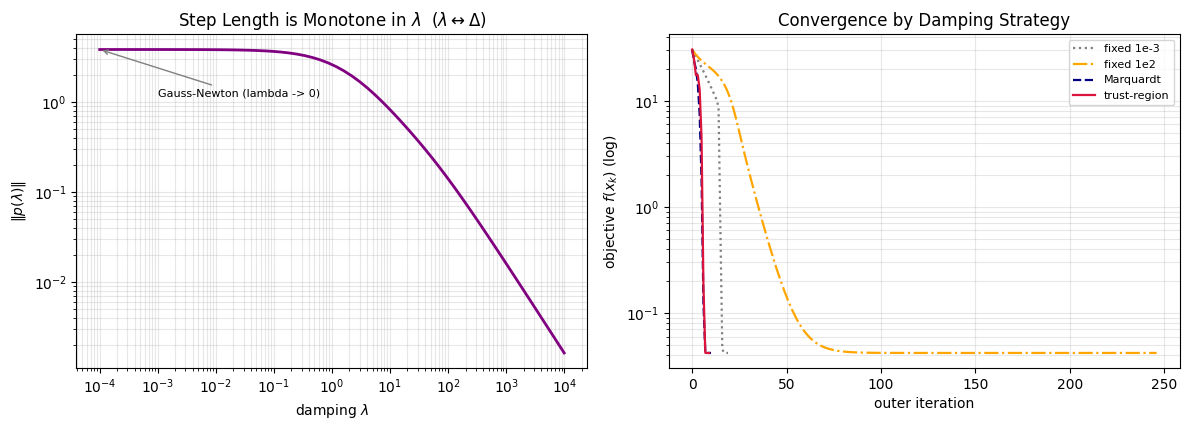

In [4]:
# --- 시각화: 단조성 + 전략별 수렴 ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].loglog(lams, pnorms, '-', color='purple', lw=2)
ax[0].set_xlabel(r'damping $\lambda$'); ax[0].set_ylabel(r'$\|p(\lambda)\|$')
ax[0].set_title(r'Step Length is Monotone in $\lambda$  ($\lambda \leftrightarrow \Delta$)')
ax[0].grid(True, which='both', alpha=0.3)
ax[0].annotate('Gauss-Newton (lambda -> 0)', xy=(lams[0], pnorms[0]), xytext=(1e-3, pnorms[0]*0.3),
               fontsize=8, arrowprops=dict(arrowstyle='->', color='gray'))

for h, lab, col, ls in [(hf_s, 'fixed 1e-3', 'gray', ':'), (hf_b, 'fixed 1e2', 'orange', '-.'),
                        (hm, 'Marquardt', 'navy', '--'), (ht, 'trust-region', 'crimson', '-')]:
    ax[1].semilogy(range(len(h)), np.maximum(h, 1e-14), ls, color=col, lw=1.6, label=lab)
ax[1].set_xlabel('outer iteration'); ax[1].set_ylabel(r'objective $f(x_k)$ (log)')
ax[1].set_title('Convergence by Damping Strategy'); ax[1].legend(fontsize=8)
ax[1].grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **단조성 = 등가성**: 좌측 그래프에서 $\|\mathbf p(\lambda)\|$ 는 $\lambda$ 에 대해 매끄럽게 단조 감소한다.
   $\lambda=0$ 의 Gauss-Newton 길이에서 시작해 $\lambda\to\infty$ 에서 0 으로 수렴하므로, 임의의 반지름
   $\Delta\in(0,\|\mathbf p^{\mathrm{GN}}\|]$ 에 대해 그것을 실현하는 $\lambda$ 가 유일하게 존재한다 -
   **"$\lambda$ 선택 = $\Delta$ 선택"** 이 수치로 확인된다.
2. **고정 $\lambda$ 의 함정**: 너무 크면($10^{2}$) 매 스텝이 짧아 수백 회를 기어가고(표의 outer/solves 가
   가장 큼), 작으면($10^{-3}$) 적응성이 없어 위기 대응을 못 한다. 어느 쪽도 *균형*을 못 잡는다.
3. **적응이 이긴다**: Marquardt 적응은 위기에서 $\lambda$ 를 키워 안전을, 수렴 구간에서 줄여 속도를 얻어
   고정 전략보다 훨씬 적은 외부 반복으로 도달한다.
4. **신뢰영역도 효율적이고 강건**: $\rho$ 기반 신뢰영역은 스텝의 *실제 성과*를 직접 보고 $\Delta$(따라서
   $\lambda$)를 조절해, Marquardt 와 비슷하게 적은 외부 반복으로 봉우리 위치/폭/높이를 모두 복원한다.
   다만 매 스텝 $\lambda$ 를 이분 탐색하므로 *선형풀이 횟수*(solves)는 다소 더 든다 - 정밀한 반지름 제어의 비용이다.

> **결론**: Levenberg-Marquardt 의 감쇠 $\lambda$ 는 단순 정칙화가 아니라 **신뢰영역 반지름과 1:1 등가**이며,
> $\lambda$(=$\Delta$)를 *적응적으로* 고르는 것이 비선형 최소제곱 효율/강건성의 핵심이다.

**다음 단원으로의 연결** - 이로써 §13.2(다변수 최소화)의 라인서치(Day 46)와 신뢰영역/최소제곱(Day 47)
한 쌍이 마무리된다. 다음은 **제약 있는 최적화 / KKT 조건과 페널티/내부점 방법**, 또는 **전역 최적화**로
이어가 trade-off(수렴차수 vs 비용 vs 안전성 vs 전역성)를 한 차원 더 확장한다.